# Non-circular RF — results (loads logged JSON)

Written brief: [`08_noncircular_rf_model_update.md`](08_noncircular_rf_model_update.md). Architecture history: [`07_classifier_architecture_ladder.ipynb`](07_classifier_architecture_ladder.ipynb).

This notebook **does not retrain**. It reads the diagnostic JSON sidecars from the 18 August 2026 non-circular RF fit.

In [1]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA = PROJECT_ROOT / "data" / "processed"
FIG = PROJECT_ROOT / "notebooks" / "figures" / "07_classifier"

diag = json.loads((DATA / "rf_noncircular_diagnostics.json").read_text())
post = json.loads((DATA / "rf_posthoc_report.json").read_text())
feat = json.loads((DATA / "rf_noncircular_feature_log.json").read_text())
sidecar = json.loads((DATA / "models" / "rf_thermoswitch_noncircular.json").read_text())

print("feature_set:", sidecar["feature_set"])
print("trained_at:", sidecar["trained_at"])
print(f"n={sidecar['n_rows']} ({sidecar['n_pos']} pos / {sidecar['n_neg']} neg), {len(sidecar['feature_columns'])} features")
print("circular excluded from X:", ", ".join(sidecar["circular_excluded"]))

feature_set: noncircular
trained_at: 2026-08-18T15:18:47.325535+00:00
n=2396 (1198 pos / 1198 neg), 92 features
circular excluded from X: nupack_Tm, nupack_hill_coeff, nupack_amplitude, viennarna_Tm, viennarna_hill_coeff, viennarna_amplitude, viennarna_mfe_zscore, viennarna_delta_P_RBS, viennarna_delta_delta_G


## CV vs the circular 20-column RF

Family holdout is the number that matters. Random-split 0.97 on the new matrix is k-mer family leakage, not a switch detector.

In [2]:
cv = pd.DataFrame(
    {
        "model": [
            "Length alone",
            "Circular 20-col RF (history)",
            "Non-circular RF",
        ],
        "random_split_AUC": [
            diag["length_alone_stratified"]["roc_auc"],
            0.80,
            diag["noncircular_stratified"]["roc_auc"],
        ],
        "family_holdout_AUC": [
            None,
            0.19,
            diag["noncircular_stratified_group"]["roc_auc"],
        ],
        "note": [
            "Length shortcut removed on this panel",
            "Tm / Hill / Z / ΔP_RBS were in X (circular)",
            "92-col X; melting scalars post-hoc only",
        ],
    }
)
display(cv.round(3))

aug = feat["aug_missing"]
print(
    f"Missing AUG (sentinel, not dropped): {aug['n_missing_aug_pos']} positives, "
    f"{aug['n_missing_aug_neg']} negatives (of {aug['n_pos']}/{aug['n_neg']})."
)

,model,random_split_AUC,family_holdout_AUC,note
0,Length alone,0.196,NaN,Length shortcut removed on this panel
1,Circular 20-col RF (history),0.800,0.190,Tm / Hill / Z / ΔP_RBS were in X (circular)
2,Non-circular RF,0.966,0.277,92-col X; melting scalars post-hoc only


Missing AUG (sentinel, not dropped): 475 positives, 590 negatives (of 1198/1198).


## Grouped permutation importance (in-sample)

Full-fit AUC = 1.0, so drops describe what the overfit forest uses — not out-of-family signal. Trinucleotides dominate.

,block,n_features,mean_AUC_drop,std_AUC_drop
3,trinucleotides,64,0.3380,0.0098
2,dinucleotides,16,0.0041,0.0004
0,static_biophysics,7,0.0000,0.0000
1,composition,3,0.0000,0.0000
4,sd_aug,2,0.0000,0.0000


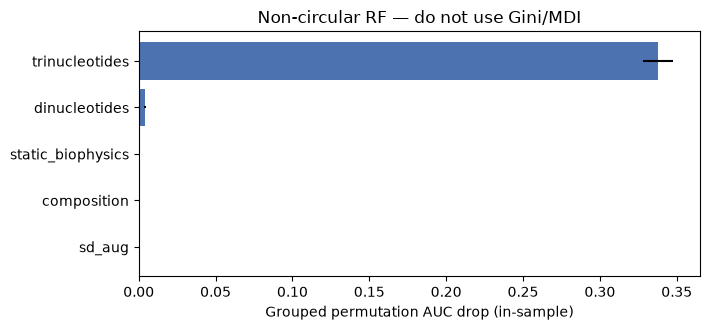

In [3]:
imp = pd.DataFrame(
    [
        {
            "block": name,
            "n_features": block["n_features"],
            "mean_AUC_drop": block["mean_auc_drop"],
            "std_AUC_drop": block["std_auc_drop"],
        }
        for name, block in diag["grouped_permutation_importance"]["groups"].items()
    ]
).sort_values("mean_AUC_drop", ascending=False)
display(imp.round(4))

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.barh(imp["block"], imp["mean_AUC_drop"], xerr=imp["std_AUC_drop"], color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Grouped permutation AUC drop (in-sample)")
ax.set_title("Non-circular RF — do not use Gini/MDI")
fig.tight_layout()

## Post-hoc (not X)

Out-of-fold \(\hat{y}\) bins, melting gates, panel-wide Spearman (primary). High-bin \(r_s\) is omitted unless \(N \ge 25\).

In [4]:
print("OOF confidence bins:", post["bins"])
print(f"High-bin Spearman underpowered: {post['high_bin_spearman_underpowered']} (n_high={post['n_high']})")

gates = pd.DataFrame(
    [{"gate": k, "n_pass": v} for k, v in post["gates"].items() if v is not None]
)
display(gates)

pairs = post["spearman_panel_wide_primary"]["pairs"]
spear = pd.DataFrame(
    [
        {"pair": name, "n": s["n"], "r_s": s["r_s"], "p": s["p_value"]}
        for name, s in pairs.items()
    ]
)
print("Panel-wide Vienna–NUPACK Spearman (primary consensus)")
display(spear.round(4))

mw = pd.DataFrame(
    [
        {
            "feature": col,
            "n_high": t["n_high"],
            "n_low": t["n_low"],
            "MW_p": t["mannwhitney_p"],
            "KS_p": t["ks_p"],
        }
        for col, t in post["bin_tests_high_vs_low"].items()
    ]
)
print("High vs low bins (exploratory: n_high = 6)")
display(mw.round(4))

OOF confidence bins: {'high_ge_0.80': 6, 'mid_0.40_0.60': 297, 'low_le_0.20': 1504, 'other': 589}
High-bin Spearman underpowered: True (n_high=6)


,gate,n_pass
0,delta_P_RBS_gt_0,2294
1,hill_gt_1,2377
2,nupack_hill_gt_1,2383
3,tm_42_45,168
4,z_le_minus2,1128


Panel-wide Vienna–NUPACK Spearman (primary consensus)


,pair,n,r_s,p
0,viennarna_Tm_vs_nupack_Tm,2396,0.0354,0.0834
1,viennarna_hill_coeff_vs_nupack_hill_coeff,2396,0.0368,0.0717
2,viennarna_amplitude_vs_nupack_amplitude,2396,0.0334,0.1026


High vs low bins (exploratory: n_high = 6)


,feature,n_high,n_low,MW_p,KS_p
0,viennarna_Tm,6,1504,0.0071,0.0022
1,viennarna_hill_coeff,6,1504,0.7369,0.3454
2,viennarna_amplitude,6,1504,0.5561,0.8581
3,viennarna_mfe_zscore,6,1504,0.6354,0.7192
4,viennarna_delta_P_RBS,6,1504,0.5523,0.4362


## Visual diagnostic checklist

Snap \(n_H > 1.5\), \(T_m\) 42–45 °C, \(\Delta\theta \ge 0.50\), baseline \(P_{\mathrm{open,RBS}}(37^\circ\mathrm{C}) \le 0.20\). Intersection on this panel is zero. EVA yield is still \(Z \le -2 \land \Delta P_{\mathrm{RBS}} > 0 \land E_{\mathrm{Rfam}} > 10^{-3}\).

,signature,n_pass
0,sigmoidal_steepness_snap,2355
1,sigmoidal_ramp,19
2,inflection_tm,168
3,dynamic_range,699
4,baseline_repression,75
5,all_four_pass,0


EVA stream FASTA triage still uses Z / ΔP_RBS / E_Rfam only. Full post-hoc Hill/Tm gates need thermo_batch on generated sequences.


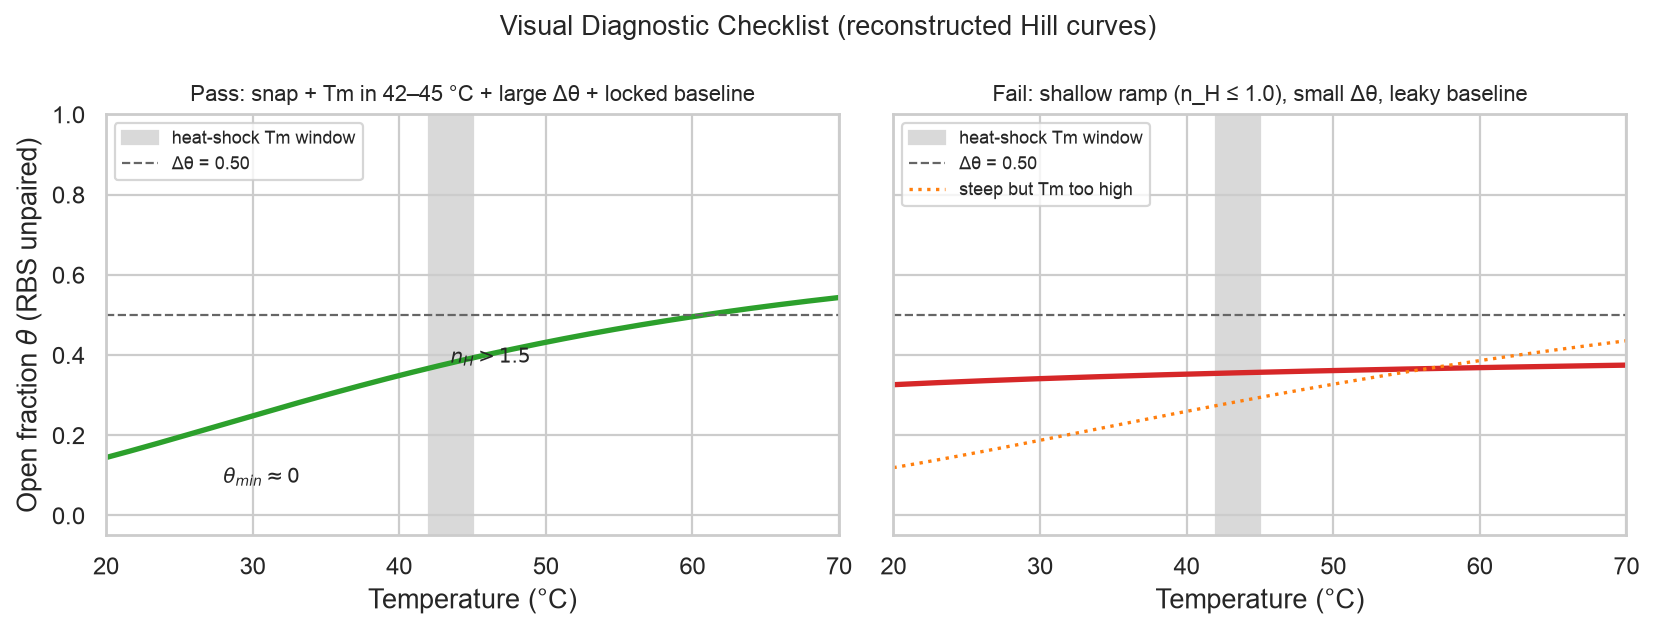

In [5]:
check = pd.DataFrame(
    [{"signature": k, "n_pass": v} for k, v in post["visual_checklist"].items()]
)
display(check)
print(post["eva_hill_not_available"])

png = FIG / "melting_visual_checklist.png"
if png.exists():
    display(Image(filename=str(png)))
else:
    print("Missing", png)